In [5]:
### Build a basic chatbot with GRAPH API


In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display


In [7]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [8]:
import os
from dotenv import load_dotenv
load_dotenv()
llm = ChatGroq(model='groq/compound')


In [9]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


In [10]:
graph_builder = StateGraph(State)
graph_builder.add_node('llamabot', chatbot)
graph_builder.add_edge(START, 'llamabot')
graph_builder.add_edge('llamabot', END)
graph = graph_builder.compile()


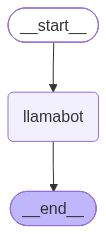

In [11]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [12]:
graph.invoke({'messages': [HumanMessage(content='Hi')]})


{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='acbb940a-fe9d-4a2b-aaa7-fad8e2710eae'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': '<Think>\n\n</Think>'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 232, 'total_tokens': 294, 'completion_time': 0.130997, 'completion_tokens_details': None, 'prompt_time': 0.033203, 'prompt_tokens_details': None, 'queue_time': 0.630407, 'total_time': 0.1642}, 'model_name': 'groq/compound', 'system_fingerprint': None, 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0bf5b-a7bd-7091-9870-4b790e980289-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 232, 'output_tokens': 62, 'total_tokens': 294})]}

In [13]:
for event in graph.stream({'messages': [HumanMessage(content='Hi How are you?')]}):
    for value in event.values():
        print(value['messages'][-1].content)


Hello! I'm doing well, thank you. How can I help you today?


In [14]:
tool = TavilySearch(max_results=2)


In [15]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a(int): first int
        b(int): second int

    Returns:
        int: output int
    """
    return a * b


In [16]:
tools = [tool, multiply]


In [17]:
llm_with_tool = llm.bind_tools(tools)
llm_with_tool


ValueError: Arg a(int) in docstring not found in function signature.

In [ ]:
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state['messages'])]}


In [ ]:
builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm', tools_condition)
builder.add_edge('tools', END)

graph = builder.compile()


In [ ]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [ ]:
response = graph.invoke({'messages': [HumanMessage(content='What is the recent AI news')]})


In [ ]:
response['messages'][-1].content


In [ ]:
for m in response['messages']:
    m.pretty.print()


In [ ]:
response = graph.invoke({'messages': [HumanMessage(content='What is 5 multiplied by 2')]})
for m in response['messages']:
    m.pretty.print()


In [ ]:
memory = MemorySaver()

builder = StateGraph(State)
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm', tools_condition)
builder.add_edge('tools', END)

graph = builder.compile(checkpointer=memory)


NameError: name 'State' is not defined

In [ ]:
config = {'configurable': {'thread_id': '1'}}
response = graph.invoke({'messages': [HumanMessage(content='My name is ___')]}, config=config)
response


In [ ]:
response['messages'][-1].content


NameError: name 'response' is not defined

In [ ]:
response = graph.invoke({'messages': [HumanMessage(content='Hey whats my name')]}, config=config)
print(response['messages'][-1].content)


NameError: name 'graph' is not defined

In [ ]:
response = graph.invoke({"messages":"Hey do you remember me" }, config=config)
print(response['messages'][-1].content)


In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [ ]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [ ]:
graph=StateGraph(State)

graph.add_node("SuperBot",superbot)

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder=graph.complie(checkpointer=memory)


from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":"1"}}

graph_builder.invoke({'messages':"Hi, My name is _____ and I like ____"}, config)

In [ ]:
config={"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':"Hi, My name is __"}, config,stream_mode="updates"):
    print(chunk)

In [ ]:
config={"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':"Hi, My name is __"}, config,stream_mode="values"):
    print(chunk)

In [ ]:
config={"configurable": {"thread_id":"4"}}

for chunk in graph_builder.stream({'messages':"I also like football"}, config,stream_mode="values"):
    print(chunk)